In [1]:
from dataset_loaders import build_data_loaders
from utils.checkpoints import load_ae_from_path
from pathlib import Path
import torch

from utils.config import DatasetConfig
from visualisation import show

In [2]:
ae_path = Path("../checkpoints/autoencoder/mnist.pt")
ae = load_ae_from_path(ae_path)

In [3]:
dataset_cfg = DatasetConfig(
    name="mnist",
    channels=3,
    height=28,
    width=28,
    num_classes=10,
    num_workers=1
)

dataloader, _ = build_data_loaders(dataset_cfg, batch_size=64)

In [4]:
images, labels = next(iter(dataloader))

with torch.no_grad():
    recon, mu, logvar = ae(images)


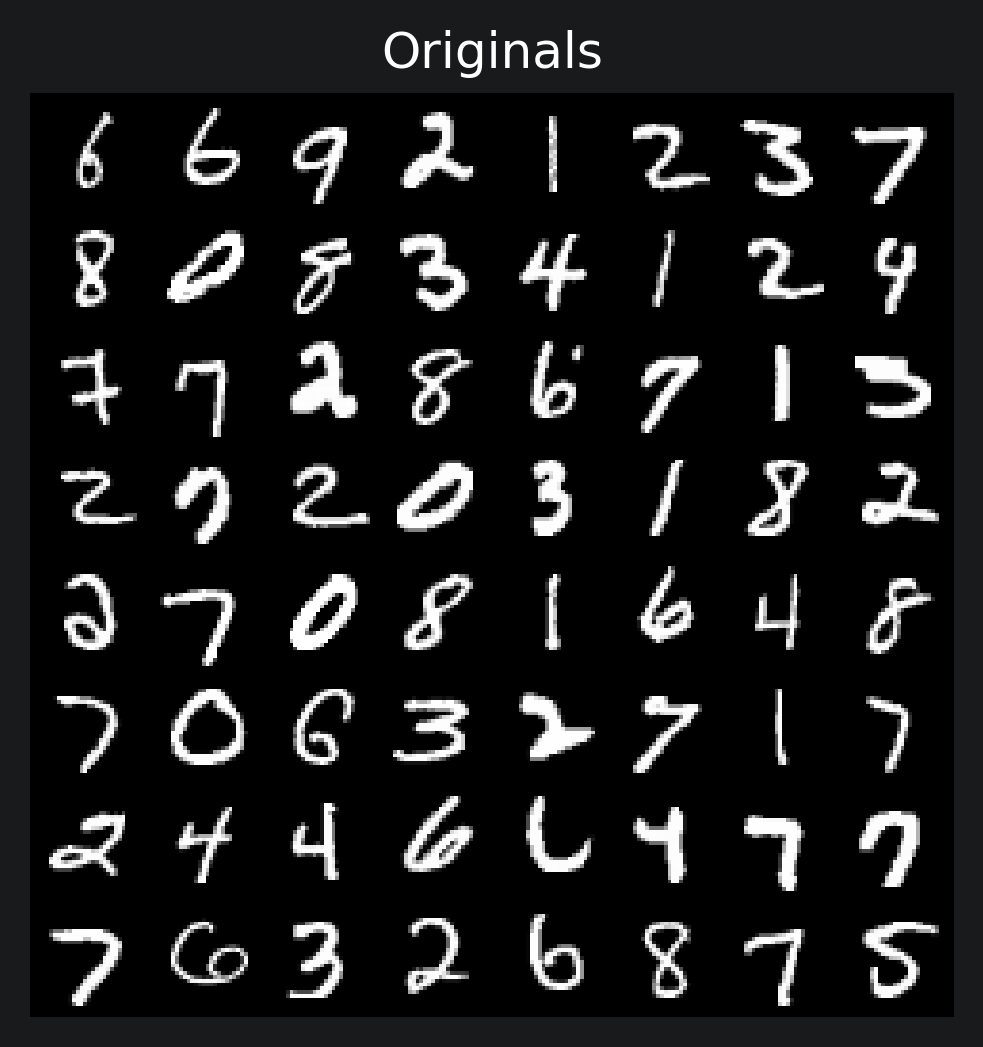

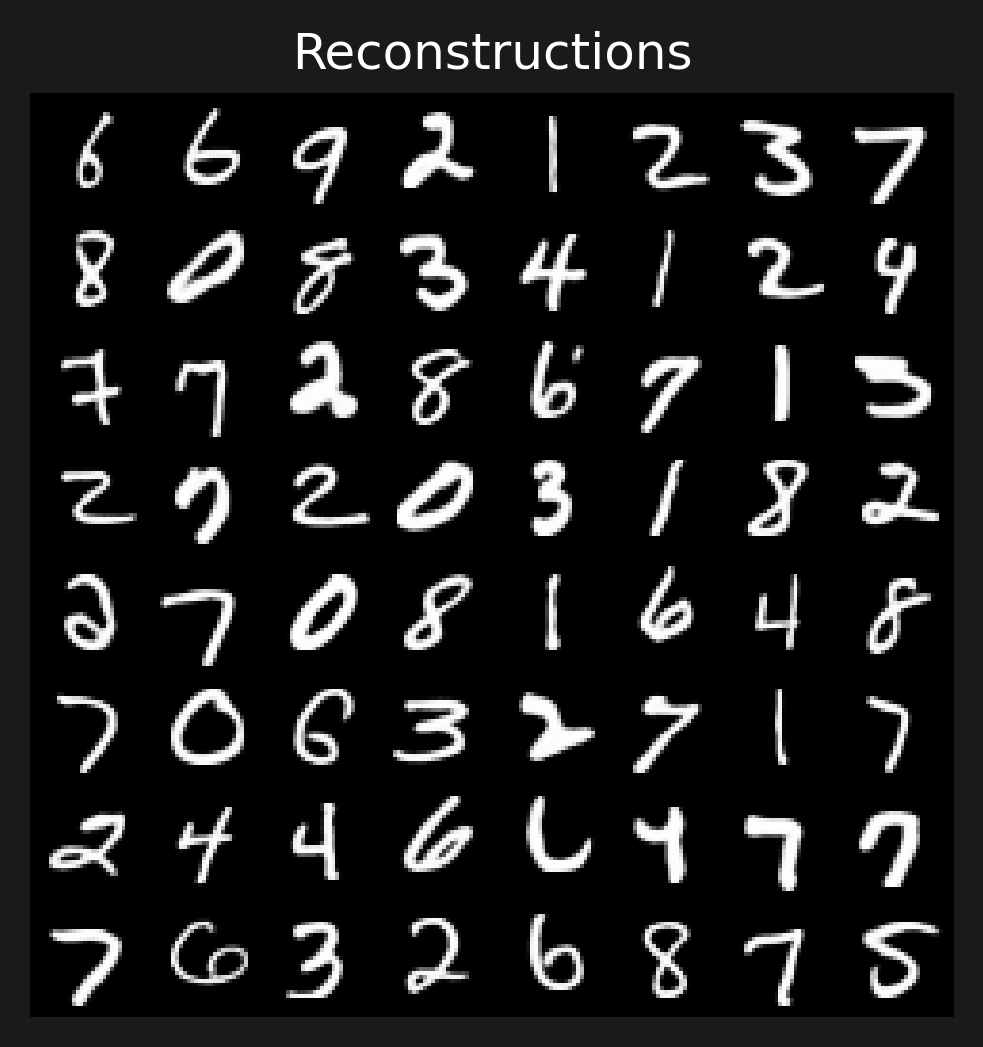

In [5]:
show(images, "Originals")
show(recon, "Reconstructions")

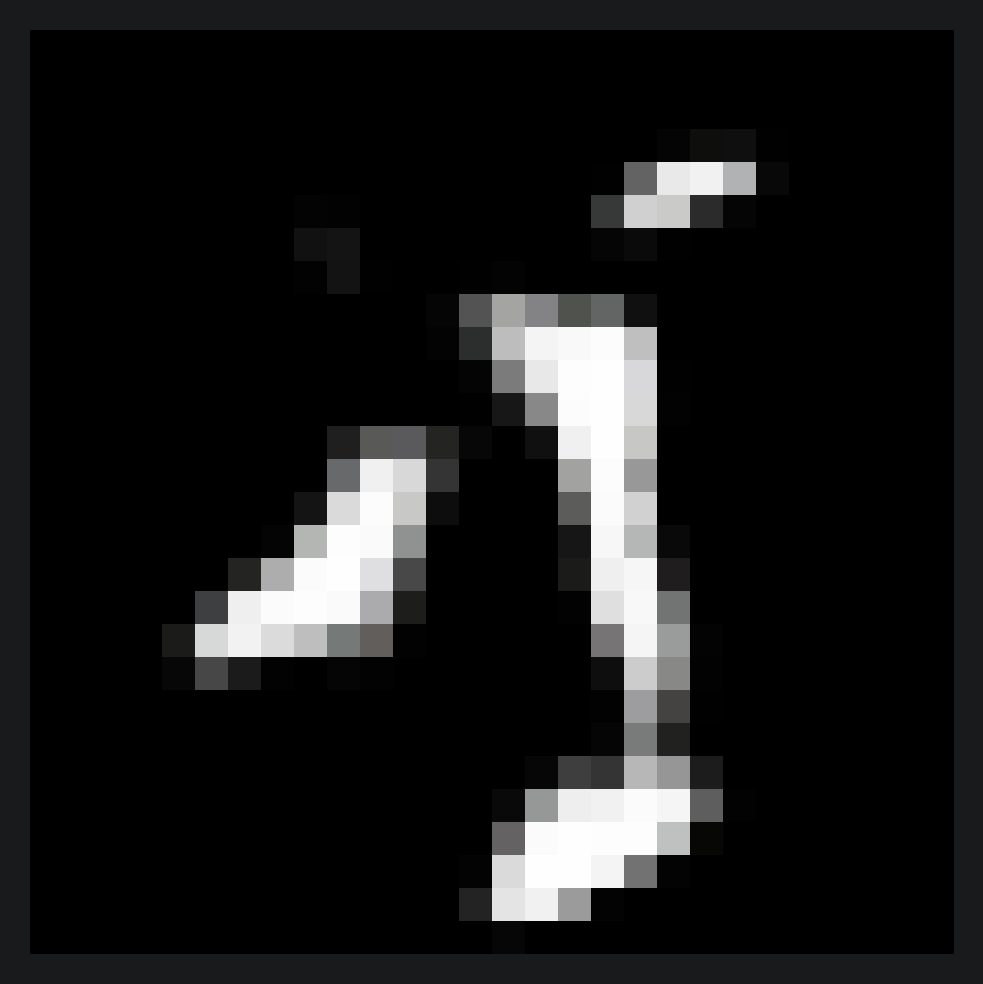

In [6]:
# decode a zero vector
z_zero = torch.rand(1, ae.latent_dim)

with torch.no_grad():
    img_zero = ae.decode(z_zero)

show(img_zero)

In [8]:
latents = ae.encode(images)
print(latents)

tensor([[ 4.6511, -2.6920,  2.1099,  ...,  3.4463,  4.2187,  8.2348],
        [ 8.3907, -3.0773, -2.7360,  ...,  4.0227, -2.2408, -2.6190],
        [ 6.5391, -4.2002,  1.8531,  ...,  9.3829,  3.5872, -2.0170],
        ...,
        [ 4.1514, -3.4031,  2.8575,  ...,  6.5560,  6.9039, -5.7150],
        [ 3.5565,  1.4327,  0.0966,  ...,  9.2565,  6.6311, -3.9642],
        [-2.2865, -2.3955, -1.7679,  ...,  7.6729, -6.3995, -3.4126]],
       grad_fn=<AddmmBackward0>)


In [9]:
print(latents.mean(dim=1))
print(latents.std(dim=1))
print(latents.min(), latents.max())

tensor([ 0.4364, -1.1912,  0.9513, -0.7207,  0.2552, -0.0145,  0.6465, -0.6260,
         0.1401, -0.2150, -1.0085, -0.4016,  0.7065,  0.0141, -1.1632, -0.4515,
         1.0381,  1.4478, -0.1044, -0.3293, -0.1953, -1.0570,  0.2618, -1.4298,
        -0.6367,  0.4373, -0.6025, -0.4086, -0.4064,  0.7048,  0.1379, -0.5716,
         0.2564,  0.1991, -0.3216, -0.2475,  0.3406, -1.0156,  1.4040, -0.5889,
        -0.0675, -0.1438,  0.4435, -1.8830, -2.8624, -1.9553,  0.0112,  0.0398,
        -0.2822,  0.5354,  1.7851, -0.2135, -2.1006,  1.3683,  1.0985,  0.9586,
        -1.0933, -1.4325,  0.2587, -0.4153, -0.5343,  0.9080,  1.3046, -0.0368],
       grad_fn=<MeanBackward1>)
tensor([4.0572, 5.1456, 5.2870, 6.7477, 3.8333, 5.9207, 7.2261, 6.6380, 5.0442,
        7.3679, 5.1937, 7.1218, 6.0486, 3.5884, 6.5822, 5.3827, 5.3283, 5.0138,
        7.6055, 5.2167, 5.4945, 6.1787, 6.1522, 7.9350, 5.4415, 6.6637, 5.8418,
        8.0663, 6.1726, 4.8230, 5.7099, 6.0323, 5.4192, 6.1633, 7.8250, 5.6533,
       